#Install Dependencies

In [1]:
!pip install -q statsmodels pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.9 MB/s eta 0:00:00


#Imports

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

#Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose, STL

#Autocorrelation & Stationarity
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Exponential Smoothing & ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110})
print('All libraries loaded.')

All libraries loaded.


#Load, Clean & Aggregate

In [5]:
DATA_PATH = 'melbourne_pedestrians.csv'

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True, errors='coerce')
df.dropna(subset=['date_time'], inplace=True)
df.sort_values('date_time', inplace=True)

# Pick the sensor with the most records (fewest gaps)
top_sensor = df.groupby('sensor_id')['hourly_counts'].count().idxmax()
df_s = df[df['sensor_id'] == top_sensor].set_index('date_time')[['hourly_counts']]

# Complete hourly index and interpolate short gaps
df_s = df_s.groupby(df_s.index).mean()
df_s = df_s.reindex(pd.date_range(df_s.index.min(), df_s.index.max(), freq='H'))
df_s['hourly_counts'] = df_s['hourly_counts'].interpolate(method='time', limit=6)
df_s.dropna(inplace=True)

# Aggregate to daily
daily = df_s.resample('D').sum()
series = daily['hourly_counts']

print(f'Sensor: {top_sensor}')
print(f'Range : {series.index[0].date()} to {series.index[-1].date()}')
print(f'Days  : {len(series)}')
daily.head()

Sensor: 8
Range : 2009-01-08 to 2022-11-08
Days  : 5053


,hourly_counts
2009-01-08,1065.0
2009-01-09,1231.0
2009-01-10,1479.0
2009-01-11,1287.0
2009-01-12,2435.0


---
# Task 1 — Temporal Preprocessing

##Raw Series & 30-Day Rolling Statistics

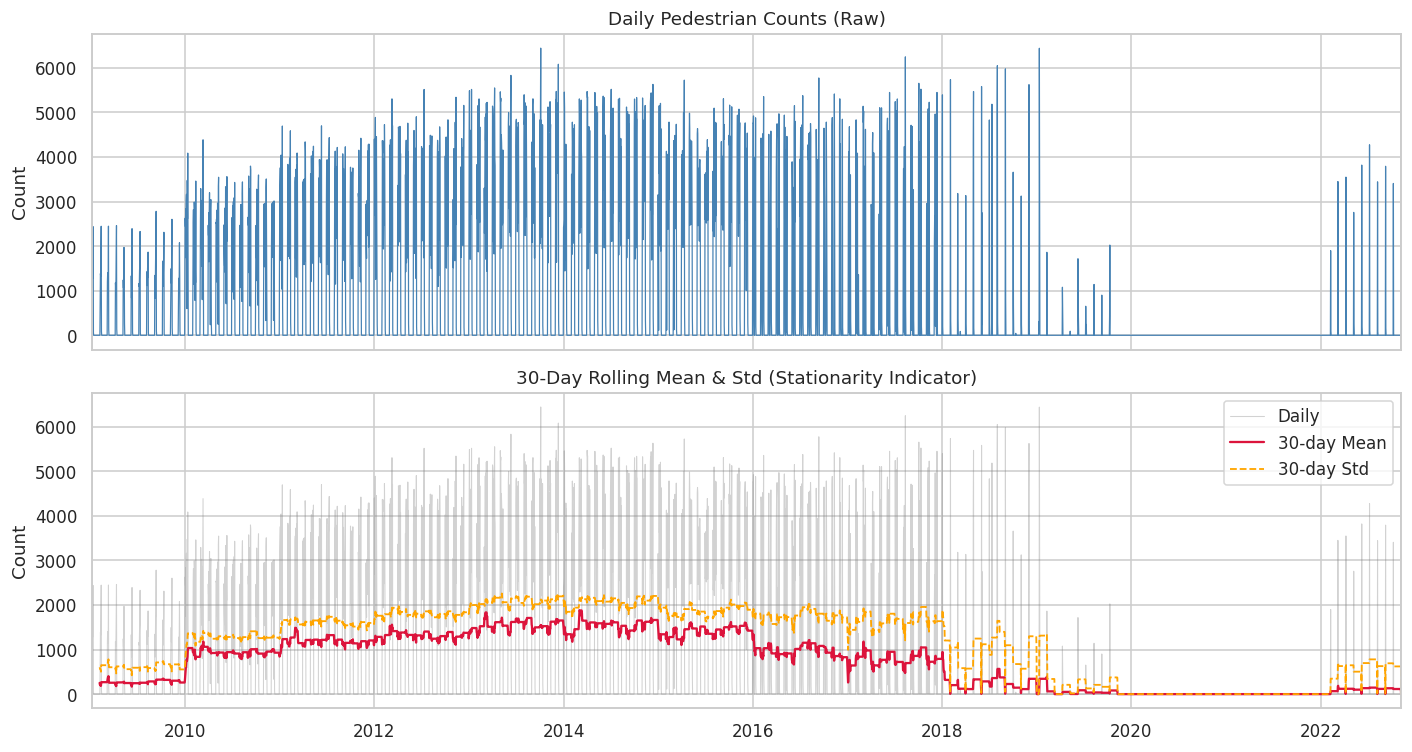

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

series.plot(ax=axes[0], color='steelblue', lw=0.8,
            title='Daily Pedestrian Counts (Raw)')
axes[0].set_ylabel('Count')

roll = series.rolling(30)
axes[1].plot(series.index, series, alpha=0.35, color='grey', lw=0.7, label='Daily')
axes[1].plot(series.index, roll.mean(), color='crimson', lw=1.5, label='30-day Mean')
axes[1].plot(series.index, roll.std(),  color='orange',  lw=1.2, ls='--', label='30-day Std')
axes[1].set_title('30-Day Rolling Mean & Std (Stationarity Indicator)')
axes[1].legend(); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig01_raw_rolling.png', bbox_inches='tight')
plt.show()

##Transformations: Log & Box-Cox

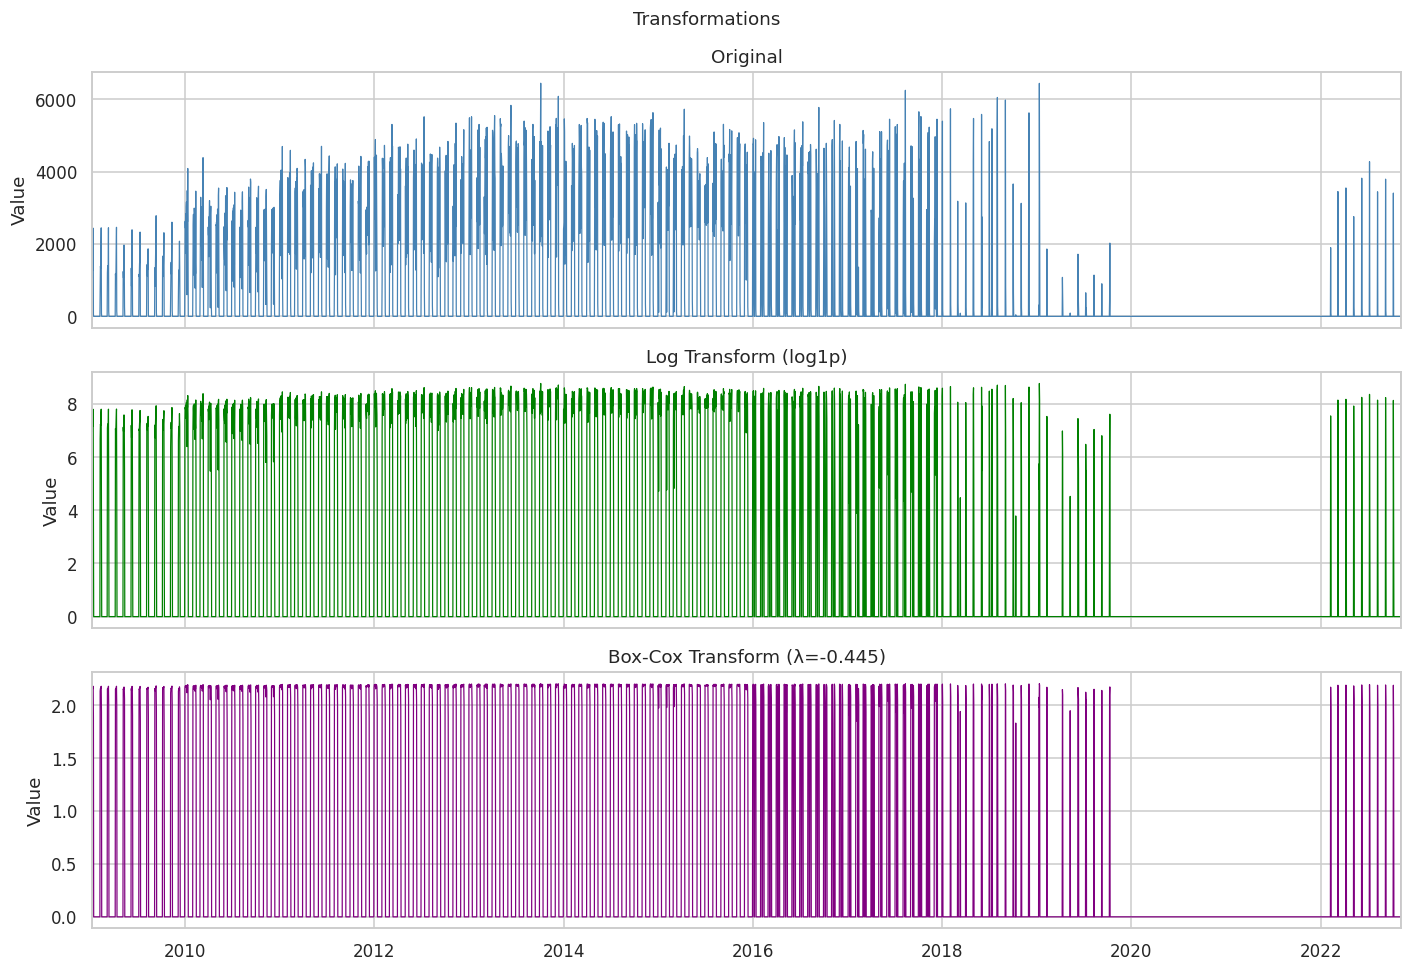

Box-Cox lambda = -0.4445


In [7]:
log_series = np.log1p(series)
bc_values, lam = sp_stats.boxcox(series + 1)
bc_series = pd.Series(bc_values, index=series.index)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
series.plot(ax=axes[0],     color='steelblue', lw=0.8, title='Original')
log_series.plot(ax=axes[1], color='green',     lw=0.8, title='Log Transform (log1p)')
bc_series.plot(ax=axes[2],  color='purple',    lw=0.8, title=f'Box-Cox Transform (λ={lam:.3f})')
for ax in axes: ax.set_ylabel('Value')
plt.suptitle('Transformations', fontsize=12)
plt.tight_layout()
plt.savefig('fig02_transformations.png', bbox_inches='tight')
plt.show()
print(f'Box-Cox lambda = {lam:.4f}')

##Moving Averages: SMA, WMA, Centred

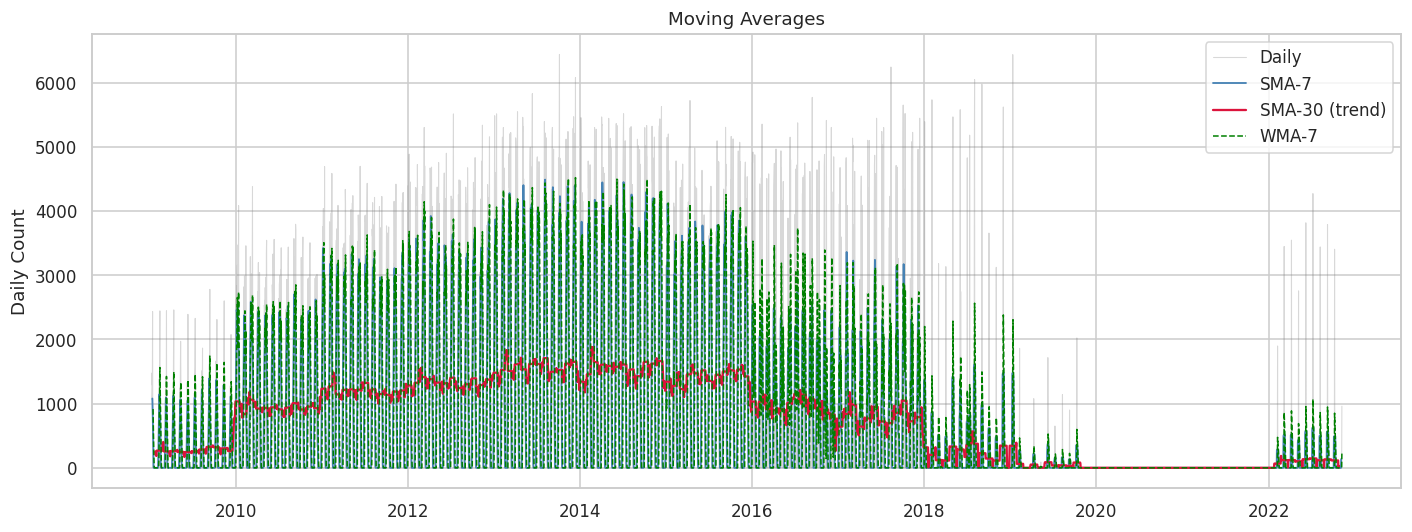

In [8]:
sma7  = series.rolling(window=7,  center=True).mean()
sma30 = series.rolling(window=30, center=True).mean()
wma_w = np.array([1,2,3,4,5,6,7], dtype=float); wma_w /= wma_w.sum()
wma7  = series.rolling(window=7).apply(lambda x: np.dot(x, wma_w), raw=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series.index, series, alpha=0.3, color='grey',      lw=0.7, label='Daily')
ax.plot(sma7.index,   sma7,  color='steelblue', lw=1.2,            label='SMA-7')
ax.plot(sma30.index,  sma30, color='crimson',   lw=1.5,            label='SMA-30 (trend)')
ax.plot(wma7.index,   wma7,  color='green',     lw=1.0, ls='--',   label='WMA-7')
ax.set_title('Moving Averages'); ax.legend(); ax.set_ylabel('Daily Count')
plt.tight_layout()
plt.savefig('fig03_moving_averages.png', bbox_inches='tight')
plt.show()

##Classical Decomposition: Additive & Multiplicative

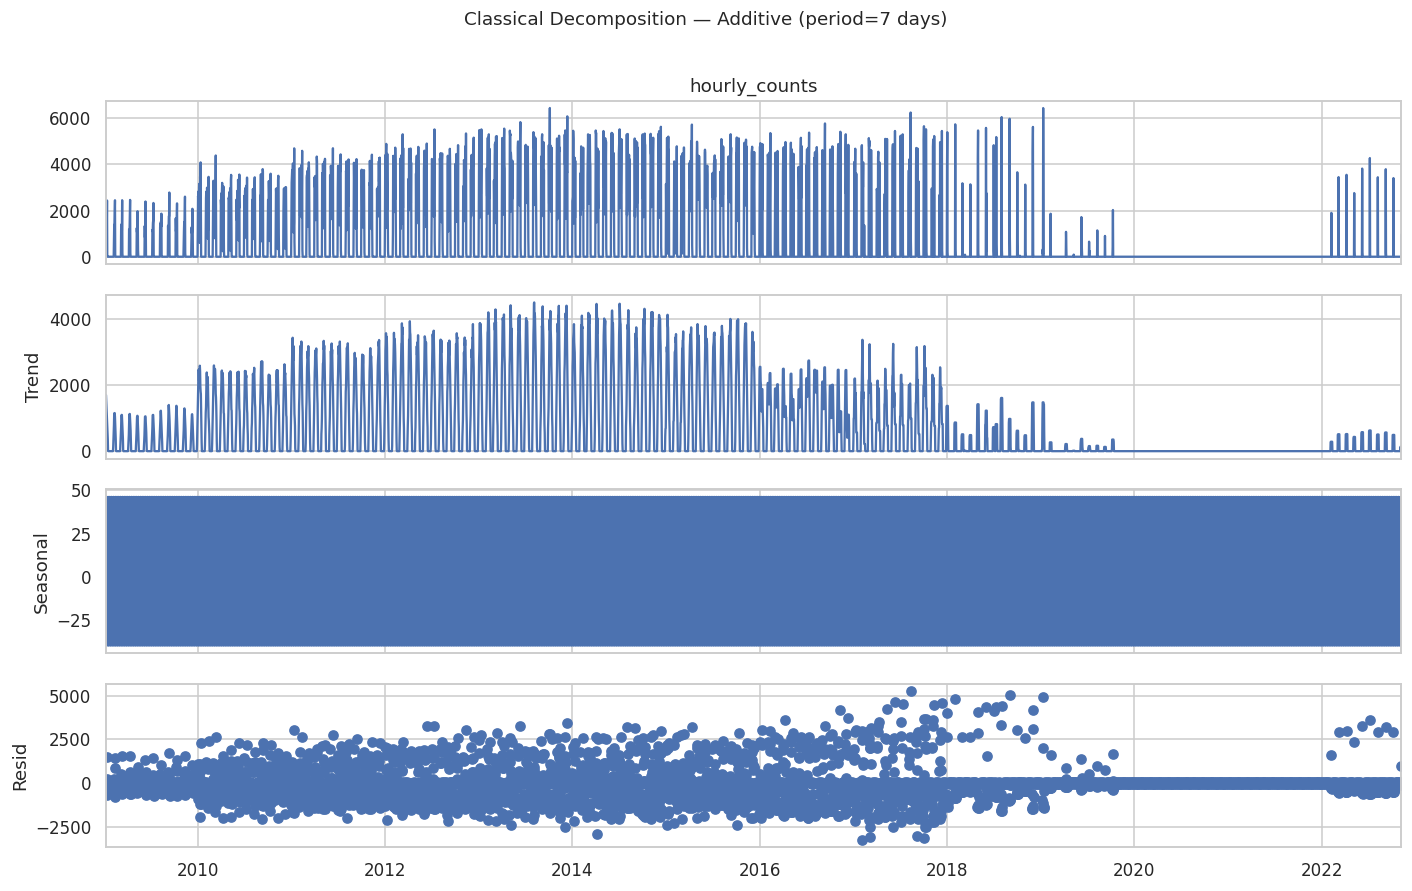

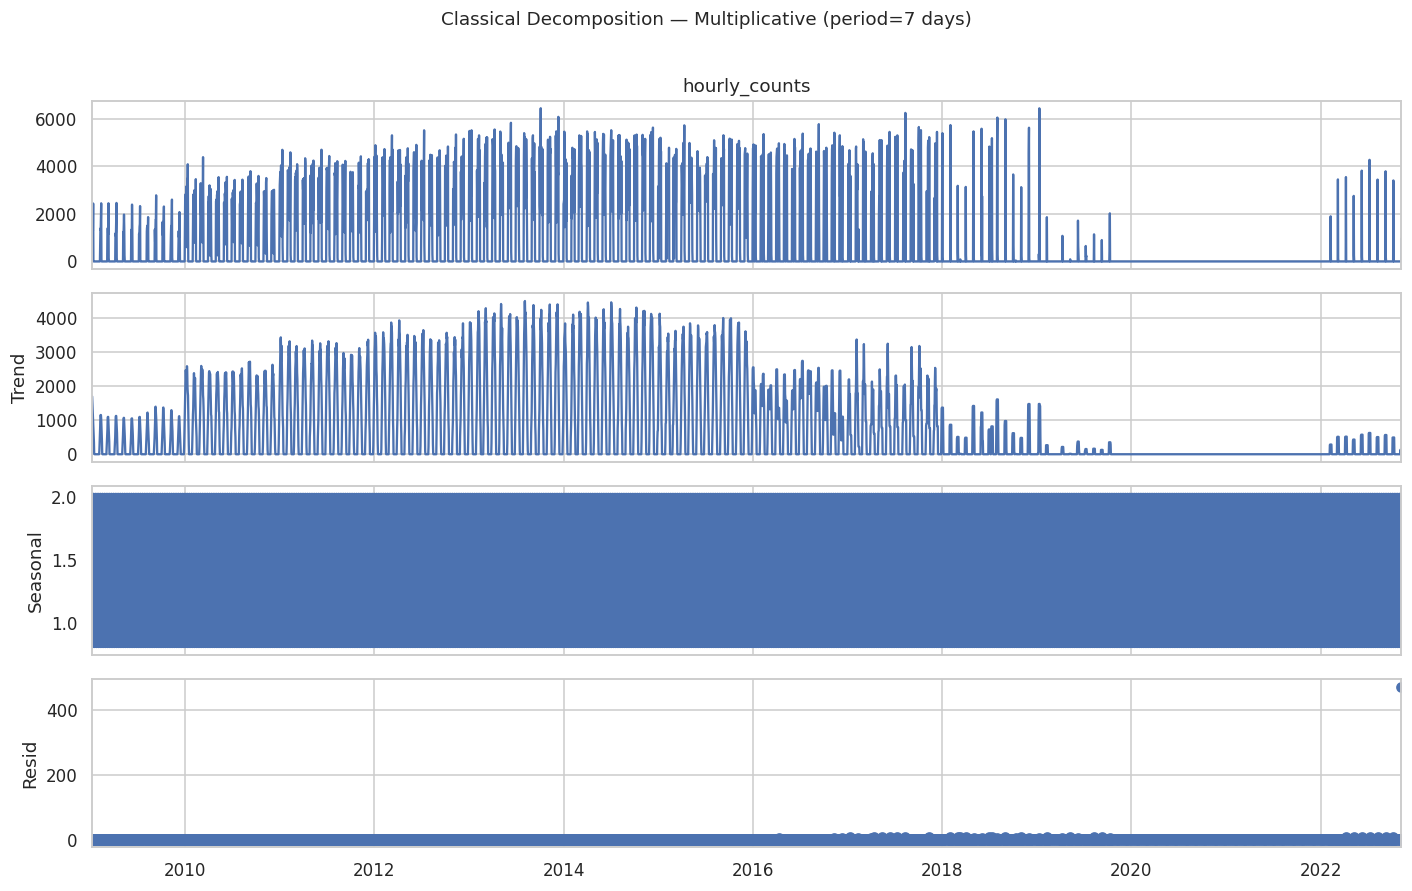

In [11]:
for model in ['additive', 'multiplicative']:
    if(model == 'multiplicative'):
        series_pos = series - series.min() + 1
    else:
        series_pos = series
    res = seasonal_decompose(series_pos, model=model, period=7, extrapolate_trend='freq')
    fig = res.plot()
    fig.set_size_inches(13, 8)
    fig.suptitle(f'Classical Decomposition — {model.capitalize()} (period=7 days)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'fig04_classical_{model}.png', bbox_inches='tight')
    plt.show()

##STL Decomposition using Loess

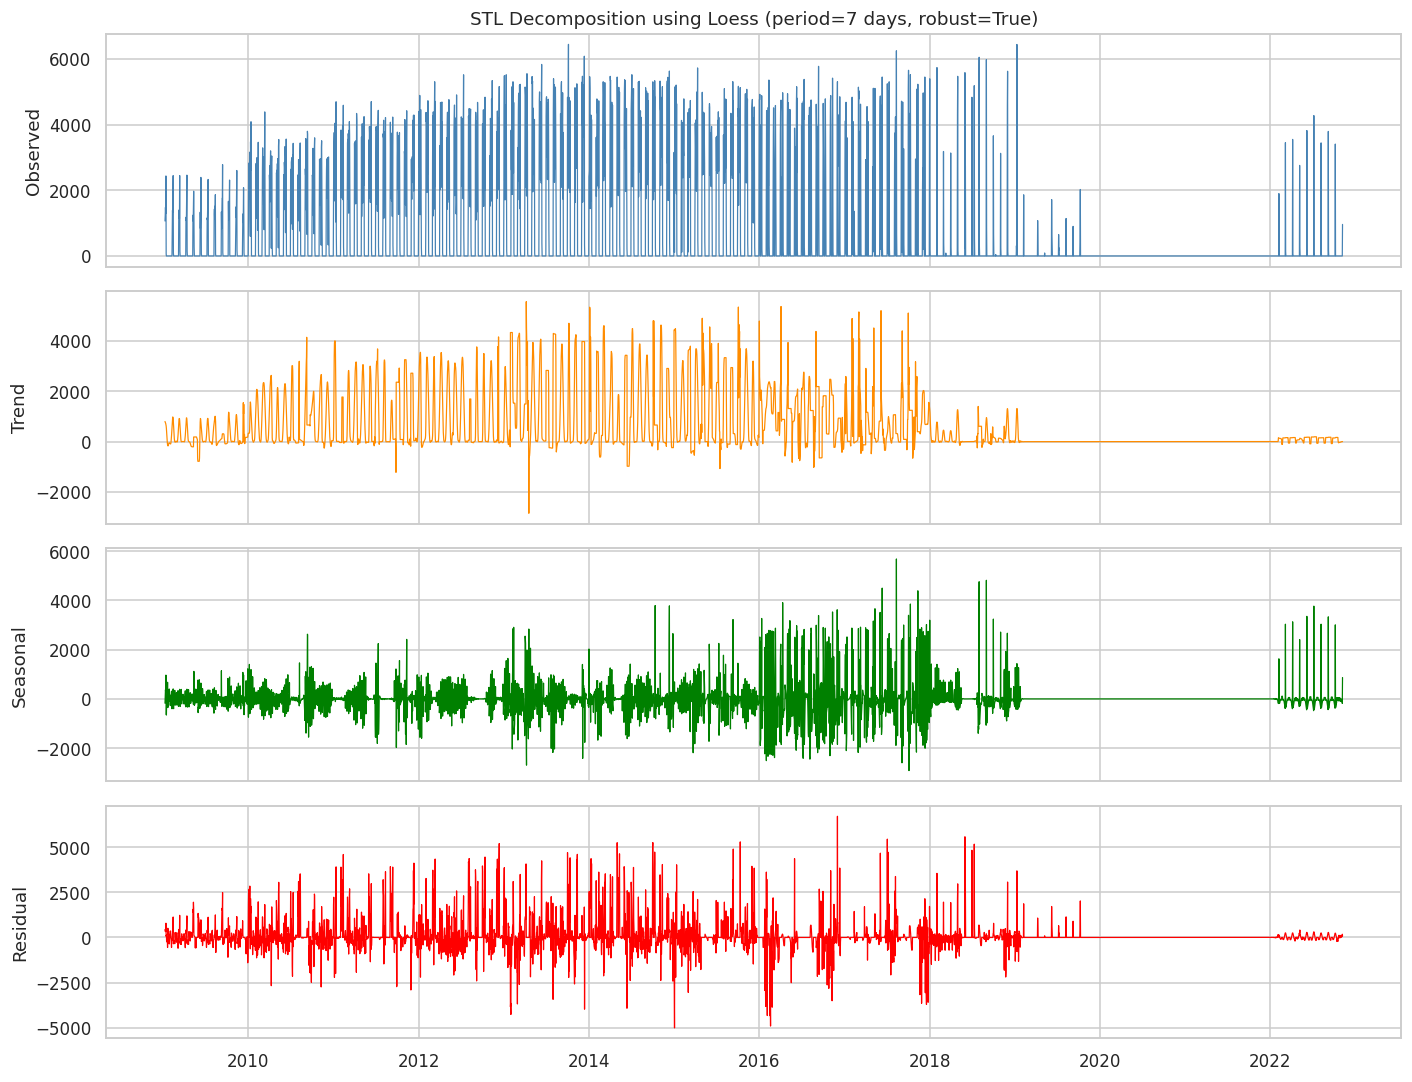

In [10]:
stl_res = STL(series, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, (data, label, color) in zip(axes, [
        (stl_res.observed, 'Observed', 'steelblue'),
        (stl_res.trend,    'Trend',    'darkorange'),
        (stl_res.seasonal, 'Seasonal', 'green'),
        (stl_res.resid,    'Residual', 'red')]):
    ax.plot(data, color=color, lw=0.8)
    ax.set_ylabel(label)

axes[0].set_title('STL Decomposition using Loess (period=7 days, robust=True)')
plt.tight_layout()
plt.savefig('fig05_stl.png', bbox_inches='tight')
plt.show()

## Detrending, Deseasonalisation & Strength of Components

Trend Strength    Ft = 0.2967  (0=none, 1=strong)
Seasonal Strength Fs = 0.6315  (0=none, 1=strong)


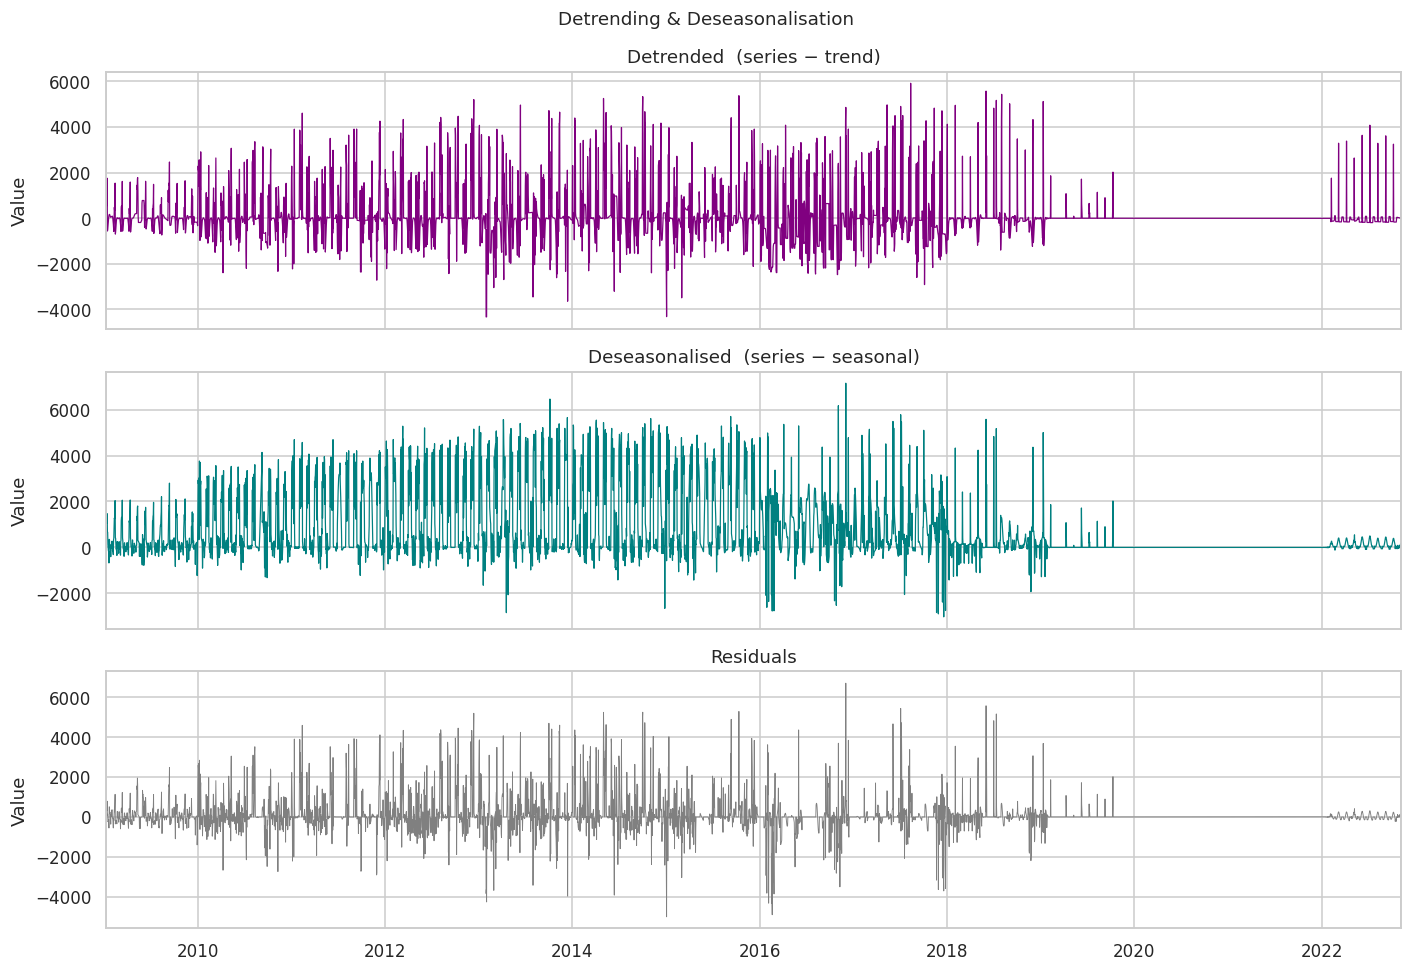

In [12]:
detrended  = series - stl_res.trend
deseasonal = series - stl_res.seasonal
residuals  = stl_res.resid

Ft = max(0, 1 - np.var(residuals) / np.var(detrended))
Fs = max(0, 1 - np.var(residuals) / np.var(deseasonal))
print(f'Trend Strength    Ft = {Ft:.4f}  (0=none, 1=strong)')
print(f'Seasonal Strength Fs = {Fs:.4f}  (0=none, 1=strong)')

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
detrended.plot( ax=axes[0], color='purple', lw=0.8, title='Detrended  (series − trend)')
deseasonal.plot(ax=axes[1], color='teal',   lw=0.8, title='Deseasonalised  (series − seasonal)')
residuals.plot( ax=axes[2], color='grey',   lw=0.6, title='Residuals')
for ax in axes: ax.set_ylabel('Value')
plt.suptitle('Detrending & Deseasonalisation', fontsize=12)
plt.tight_layout()
plt.savefig('fig06_detrend_deseasonal.png', bbox_inches='tight')
plt.show()

---
# Task 2 — Autocorrelation & Stationarity Analysis

##ACF & PACF Plots

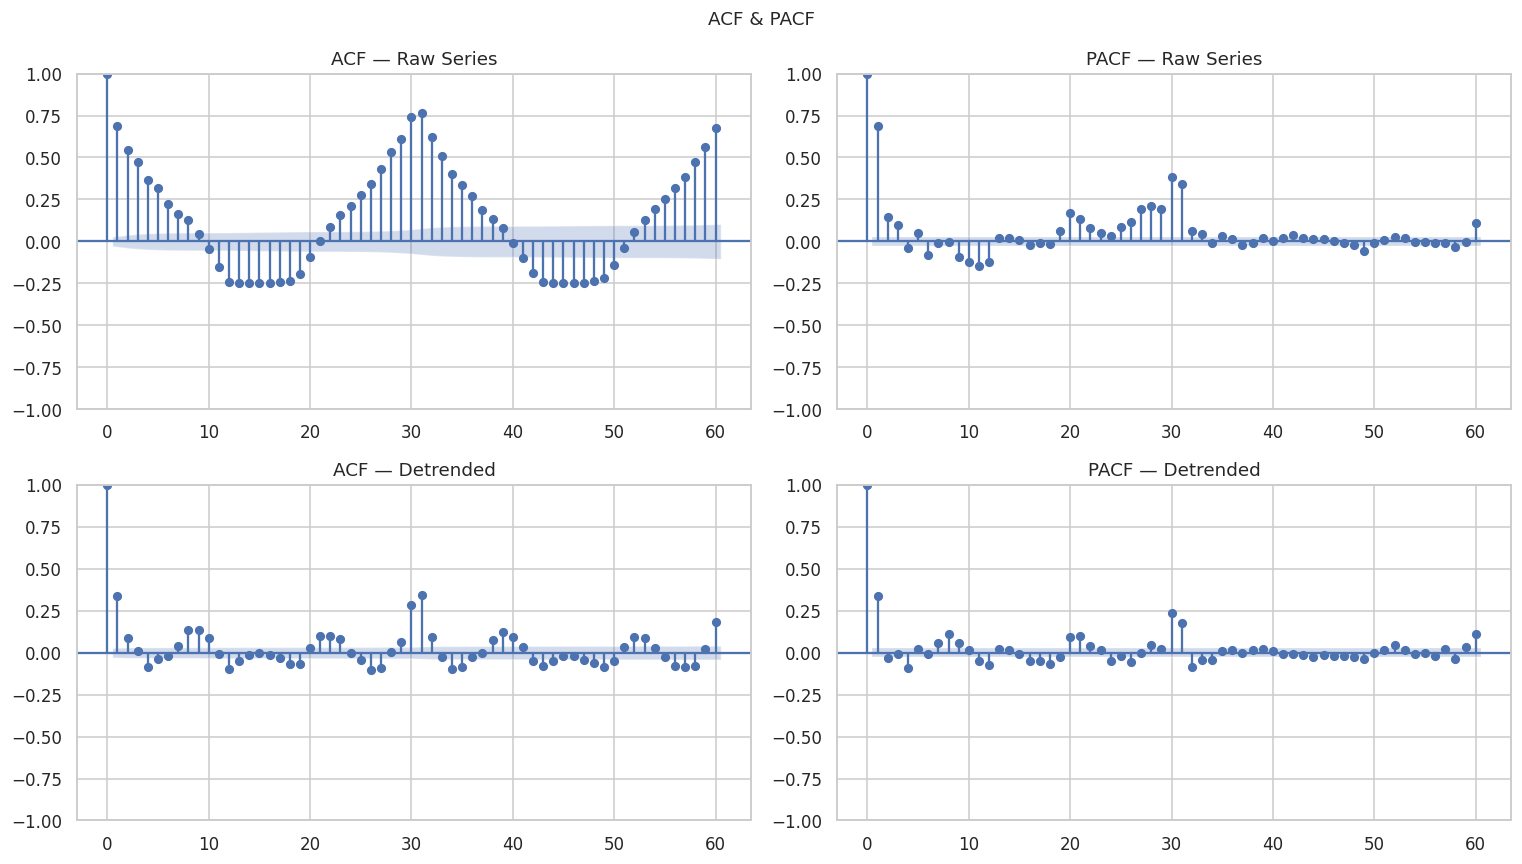


ACF at key lags:
  lag=  1: 0.6870
  lag=  7: 0.1655
  lag= 14: -0.2478
  lag= 30: 0.7416
  lag= 90: 0.6208
  lag=182: 0.6287
  lag=365: 0.6880


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( series,    lags=60, ax=axes[0,0], title='ACF — Raw Series')
plot_pacf(series,    lags=60, ax=axes[0,1], title='PACF — Raw Series', method='ywmle')
plot_acf( detrended, lags=60, ax=axes[1,0], title='ACF — Detrended')
plot_pacf(detrended, lags=60, ax=axes[1,1], title='PACF — Detrended', method='ywmle')

plt.suptitle('ACF & PACF', fontsize=12)
plt.tight_layout()
plt.savefig('fig07_acf_pacf.png', bbox_inches='tight')
plt.show()

# Autocorrelation values at key lags
acf_vals = acf(series, nlags=365, fft=True)
print('\nACF at key lags:')
for lag in [1, 7, 14, 30, 90, 182, 365]:
    if lag < len(acf_vals):
        print(f'  lag={lag:>3}: {acf_vals[lag]:.4f}')

##ADF Stationarity Test

In [14]:
def adf_test(s, label):
    stat, p, lags, _, crits, _ = adfuller(s.dropna(), autolag='AIC')
    print(f'\nADF Test [{label}]')
    print(f'  Statistic : {stat:.4f}   p-value : {p:.6f}   Lags used : {lags}')
    for k, v in crits.items():
        print(f'  Critical {k} : {v:.4f}')
    print(f'  Result    : {"Stationary ✓" if p < 0.05 else "Non-stationary ✗"}')
    return p

print('=' * 55)
adf_test(series,                   'Raw Daily')
adf_test(detrended,                'Detrended')
adf_test(deseasonal,               'Deseasonalised')
adf_test(series.diff().dropna(),   '1st Difference')
adf_test(series.diff(7).dropna(),  'Seasonal Difference (lag=7)')


ADF Test [Raw Daily]
  Statistic : -1.6723   p-value : 0.445456   Lags used : 32
  Critical 1% : -3.4317
  Critical 5% : -2.8621
  Critical 10% : -2.5671
  Result    : Non-stationary ✗

ADF Test [Detrended]
  Statistic : -8.8339   p-value : 0.000000   Lags used : 32
  Critical 1% : -3.4317
  Critical 5% : -2.8621
  Critical 10% : -2.5671
  Result    : Stationary ✓

ADF Test [Deseasonalised]
  Statistic : -1.6617   p-value : 0.450931   Lags used : 32
  Critical 1% : -3.4317
  Critical 5% : -2.8621
  Critical 10% : -2.5671
  Result    : Non-stationary ✗

ADF Test [1st Difference]
  Statistic : -43.1118   p-value : 0.000000   Lags used : 31
  Critical 1% : -3.4317
  Critical 5% : -2.8621
  Critical 10% : -2.5671
  Result    : Stationary ✓

ADF Test [Seasonal Difference (lag=7)]
  Statistic : -23.7614   p-value : 0.000000   Lags used : 32
  Critical 1% : -3.4317
  Critical 5% : -2.8621
  Critical 10% : -2.5671
  Result    : Stationary ✓


0.0

## Visual Stationarity Check

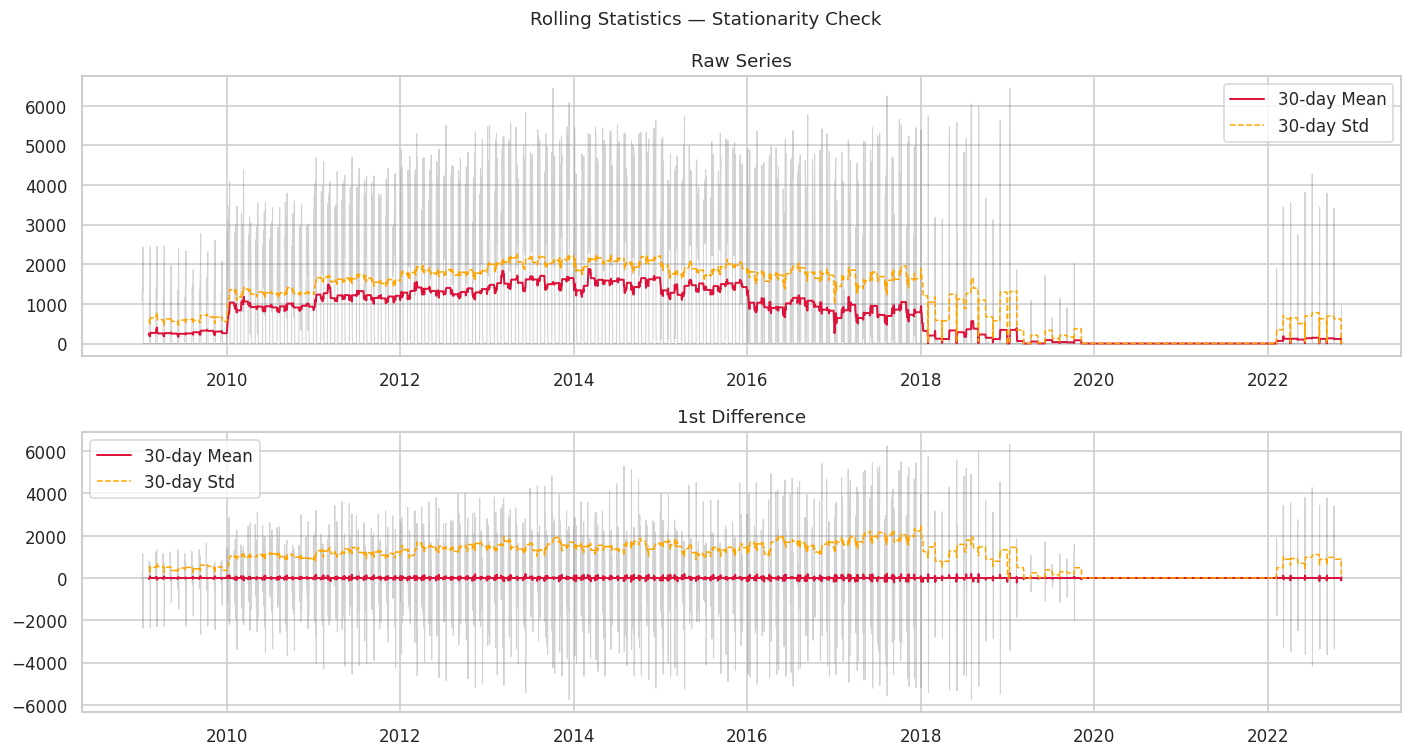

In [15]:
diff1 = series.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
for ax, (s, label) in zip(axes, [(series, 'Raw Series'), (diff1, '1st Difference')]):
    r = s.rolling(30)
    ax.plot(s.index, s,          alpha=0.35, color='grey',   lw=0.7)
    ax.plot(r.mean().index, r.mean(), color='crimson', lw=1.3, label='30-day Mean')
    ax.plot(r.std().index,  r.std(),  color='orange',  lw=1.0, ls='--', label='30-day Std')
    ax.set_title(label); ax.legend()

plt.suptitle('Rolling Statistics — Stationarity Check', fontsize=12)
plt.tight_layout()
plt.savefig('fig08_stationarity.png', bbox_inches='tight')
plt.show()

---
# Task 3 — Temporal Regression & Forecasting

##Train / Test Split (30-day holdout)

In [16]:
HOLDOUT = 30
train = series.iloc[:-HOLDOUT]
test  = series.iloc[-HOLDOUT:]

print(f'Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)')
print(f'Test : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)')

def metrics(actual, predicted, name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-9))) * 100
    r2   = r2_score(actual, predicted)
    print(f'  {name:<42} MAE={mae:>8.1f}  RMSE={rmse:>8.1f}  MAPE={mape:>6.2f}%  R²={r2:.3f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []

Train: 2009-01-08 → 2022-10-09 (5023 days)
Test : 2022-10-10  → 2022-11-08  (30 days)


##Linear Regression with Fourier Features

  Linear Regression (Fourier + Trend)        MAE=   181.7  RMSE=   216.8  MAPE=15486593327141.95%  R²=-0.582


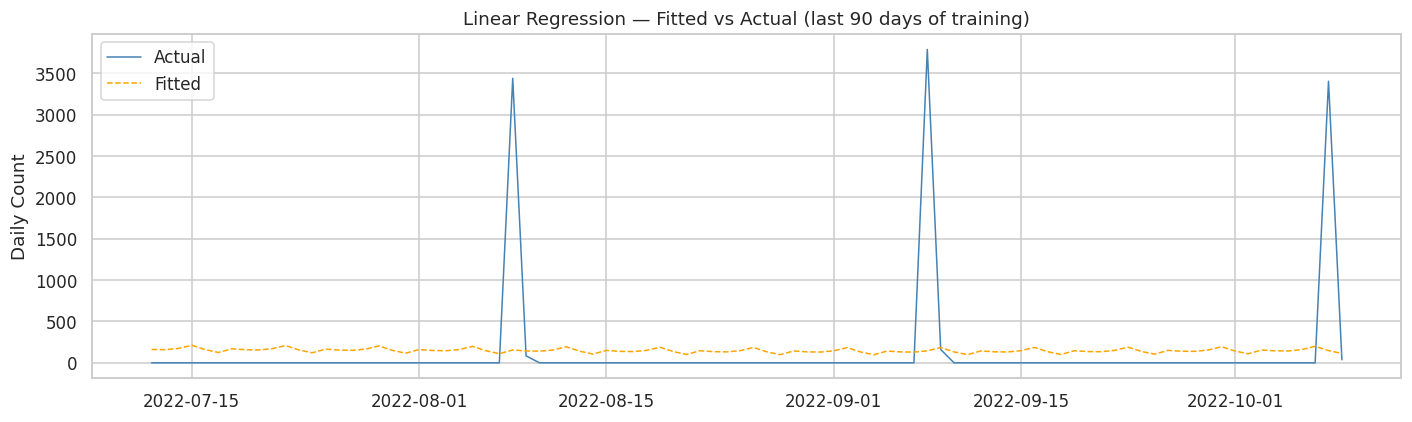

In [17]:
def calendar_features(idx):
    feats = {'trend': np.arange(len(idx))}
    for k in [1, 2, 3]:
        feats[f'sin_w{k}'] = np.sin(2*np.pi*k*idx.dayofweek / 7)
        feats[f'cos_w{k}'] = np.cos(2*np.pi*k*idx.dayofweek / 7)
        feats[f'sin_y{k}'] = np.sin(2*np.pi*k*idx.dayofyear / 365.25)
        feats[f'cos_y{k}'] = np.cos(2*np.pi*k*idx.dayofyear / 365.25)
    return pd.DataFrame(feats, index=idx)

X_all = calendar_features(series.index)
X_tr, X_te = X_all.iloc[:-HOLDOUT], X_all.iloc[-HOLDOUT:]

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

lr = LinearRegression().fit(X_tr_sc, train.values)
pred_lr = np.clip(lr.predict(X_te_sc), 0, None)

results.append(metrics(test.values, pred_lr, 'Linear Regression (Fourier + Trend)'))

# Plot fitted vs actual on training period
train_pred = np.clip(lr.predict(X_tr_sc), 0, None)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index[-90:], train.values[-90:], color='steelblue', lw=1.0, label='Actual')
ax.plot(train.index[-90:], train_pred[-90:],   color='orange',    lw=1.0, ls='--', label='Fitted')
ax.set_title('Linear Regression — Fitted vs Actual (last 90 days of training)')
ax.legend(); ax.set_ylabel('Daily Count')
plt.tight_layout(); plt.show()

##Forecasting with STL Decomposition

In [18]:
# Refit STL on training data only
stl_train = STL(train, period=7, robust=True).fit()

# Project trend via linear extrapolation
t_idx  = np.arange(len(train))
slope, intercept = np.polyfit(t_idx, stl_train.trend.values, 1)
trend_fc = np.array([slope*(len(train)+i) + intercept for i in range(HOLDOUT)])

# Repeat last seasonal cycle
seas = stl_train.seasonal.values
seasonal_fc = np.array([seas[-(7 - i % 7)] for i in range(HOLDOUT)])

pred_decomp = np.clip(trend_fc + seasonal_fc, 0, None)
results.append(metrics(test.values, pred_decomp, 'Forecast via STL Decomposition'))

  Forecast via STL Decomposition             MAE=   430.0  RMSE=  1103.9  MAPE=39799010641530.20%  R²=-40.039


## Holt-Winters Exponential Smoothing

In [19]:
hw = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7,
    damped_trend=True
).fit(optimized=True)

pred_hw = np.clip(hw.forecast(HOLDOUT).values, 0, None)
results.append(metrics(test.values, pred_hw, 'Holt-Winters (additive + damped trend)'))

print(f'Alpha (level)    = {hw.params["smoothing_level"]:.4f}')
print(f'Beta  (trend)    = {hw.params["smoothing_trend"]:.4f}')
print(f'Gamma (seasonal) = {hw.params["smoothing_seasonal"]:.4f}')

  Holt-Winters (additive + damped trend)     MAE=   839.5  RMSE=   850.3  MAPE=83511943810278.70%  R²=-23.348
Alpha (level)    = 0.6045
Beta  (trend)    = 0.0000
Gamma (seasonal) = 0.0001


##ARIMA (auto order via AIC)

In [20]:
print('Auto-selecting ARIMA order (non-seasonal) ...')
auto = auto_arima(
    train.values,
    d=None, max_p=4, max_q=4,
    seasonal=False, stepwise=True,
    information_criterion='aic',
    suppress_warnings=True, error_action='ignore'
)
print(f'Selected order: ARIMA{auto.order}')
print(auto.summary())

arima_fit = ARIMA(train, order=auto.order).fit()
pred_arima = np.clip(arima_fit.forecast(HOLDOUT).values, 0, None)
results.append(metrics(test.values, pred_arima, f'ARIMA{auto.order}'))

Auto-selecting ARIMA order (non-seasonal) ...
Selected order: ARIMA(2, 1, 4)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5023
Model:               SARIMAX(2, 1, 4)   Log Likelihood              -42353.747
Date:                Thu, 19 Mar 2026   AIC                          84721.493
Time:                        09:56:54   BIC                          84767.144
Sample:                             0   HQIC                         84737.490
                               - 5023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1172      0.078    -14.321      0.000      -1.270      -0.964
ar.L2         -0.7278      0.079     -9.250      0.000

##SARIMA with Weekly Seasonality

In [21]:
print('Auto-selecting SARIMA order (m=7) ...')
sarima_auto = auto_arima(
    train.values,
    d=None, max_p=3, max_q=3,
    seasonal=True, m=7,
    D=None, max_P=1, max_Q=1,
    stepwise=True, information_criterion='aic',
    suppress_warnings=True, error_action='ignore'
)
print(f'Selected: SARIMA{sarima_auto.order}x{sarima_auto.seasonal_order}')
print(sarima_auto.summary())

sarima_fit = SARIMAX(
    train,
    order=sarima_auto.order,
    seasonal_order=sarima_auto.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima = np.clip(sarima_fit.forecast(HOLDOUT).values, 0, None)
results.append(metrics(test.values, pred_sarima,
                        f'SARIMA{sarima_auto.order}x{sarima_auto.seasonal_order}'))

Auto-selecting SARIMA order (m=7) ...
Selected: SARIMA(1, 1, 3)x(1, 0, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 5023
Model:             SARIMAX(1, 1, 3)x(1, 0, [1], 7)   Log Likelihood              -42359.810
Date:                             Thu, 19 Mar 2026   AIC                          84733.620
Time:                                     10:14:09   BIC                          84779.271
Sample:                                          0   HQIC                         84749.616
                                            - 5023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7948      0.

##Forecast Comparison Plot

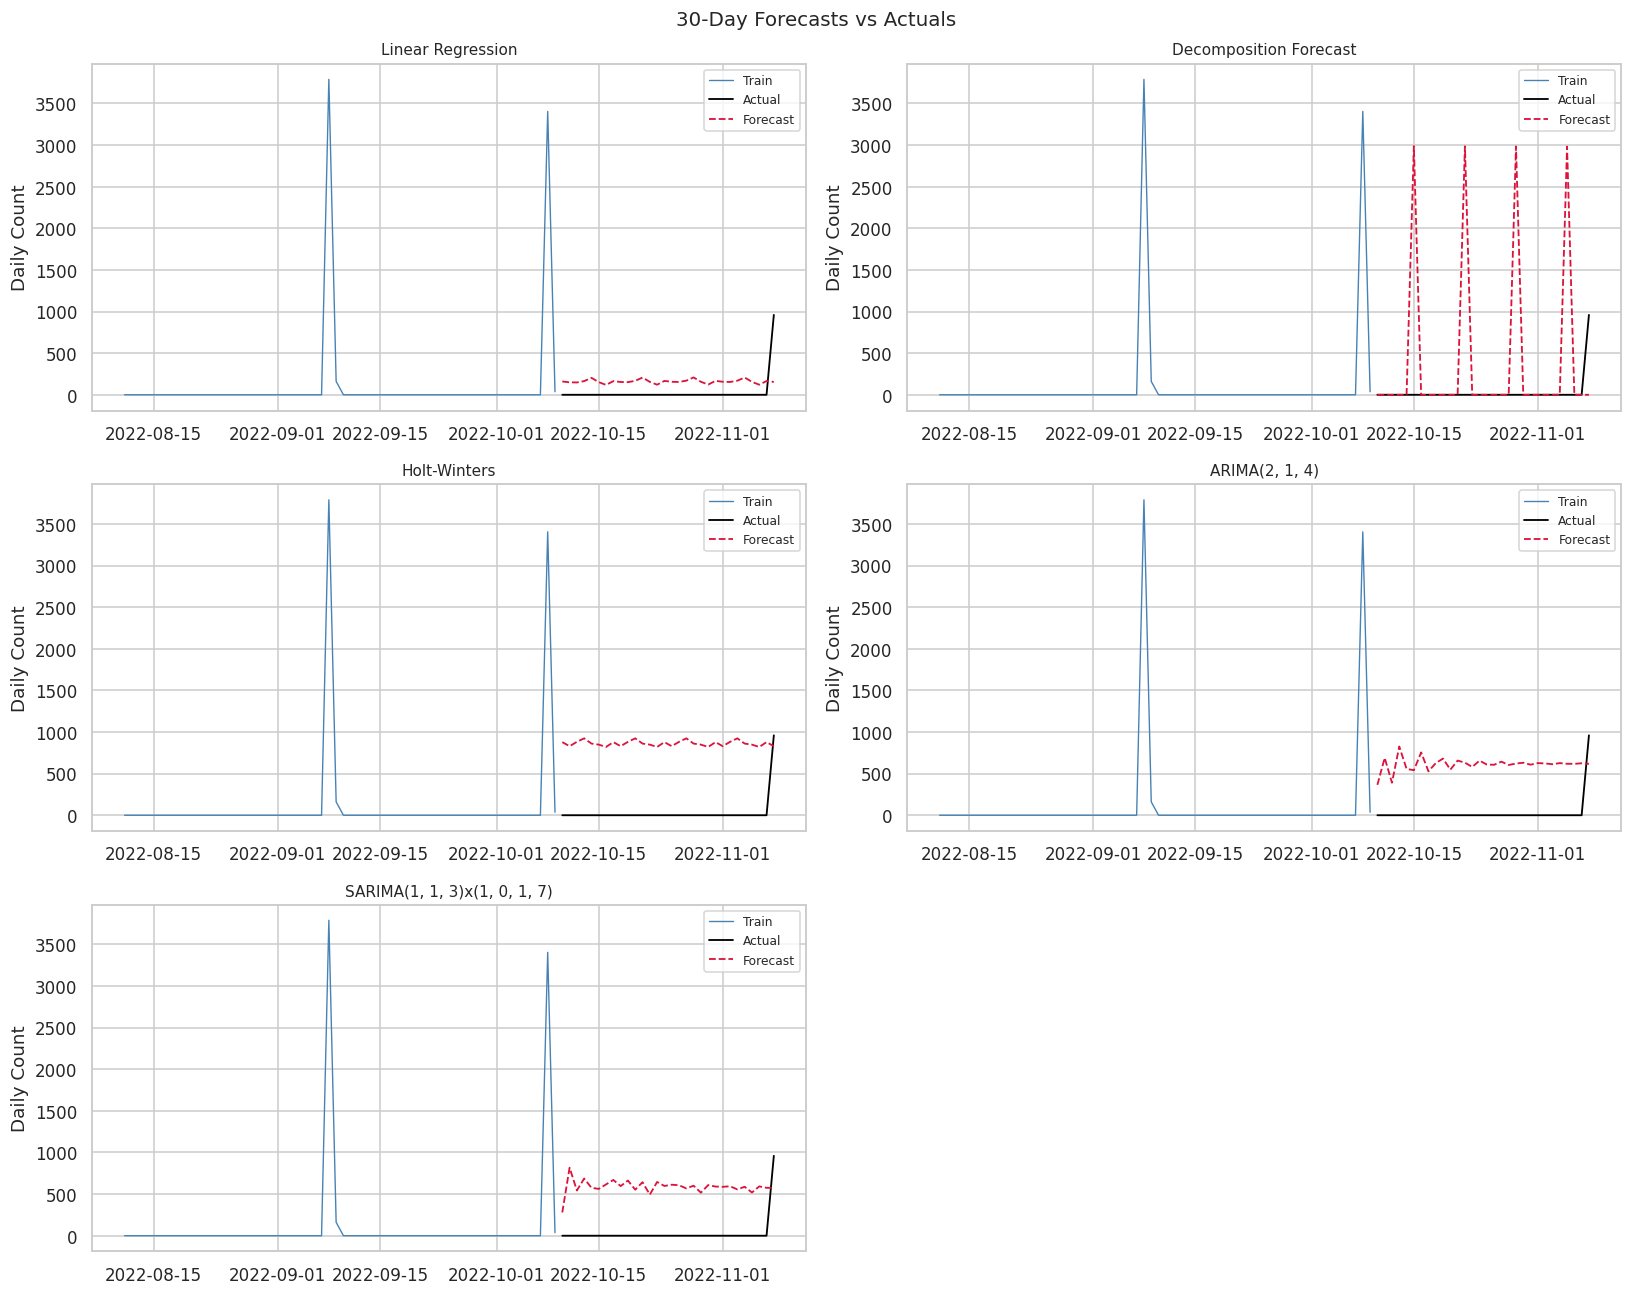

In [22]:
context = train.iloc[-60:]   # last 60 days of training for visual context

all_preds = [pred_lr, pred_decomp, pred_hw, pred_arima, pred_sarima]
all_names = [
    'Linear Regression',
    'Decomposition Forecast',
    'Holt-Winters',
    f'ARIMA{auto.order}',
    f'SARIMA{sarima_auto.order}x{sarima_auto.seasonal_order}'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, name, pred in zip(axes, all_names, all_preds):
    ax.plot(context.index, context.values, color='steelblue', lw=0.9, label='Train')
    ax.plot(test.index,    test.values,    color='black',     lw=1.2, label='Actual')
    ax.plot(test.index,    pred,           color='crimson',   lw=1.2, ls='--', label='Forecast')
    ax.set_title(name, fontsize=10); ax.legend(fontsize=8)
    ax.set_ylabel('Daily Count')

axes[-1].axis('off')
plt.suptitle('30-Day Forecasts vs Actuals', fontsize=13)
plt.tight_layout()
plt.savefig('fig09_forecast_comparison.png', bbox_inches='tight')
plt.show()

##SARIMA Residual Diagnostics

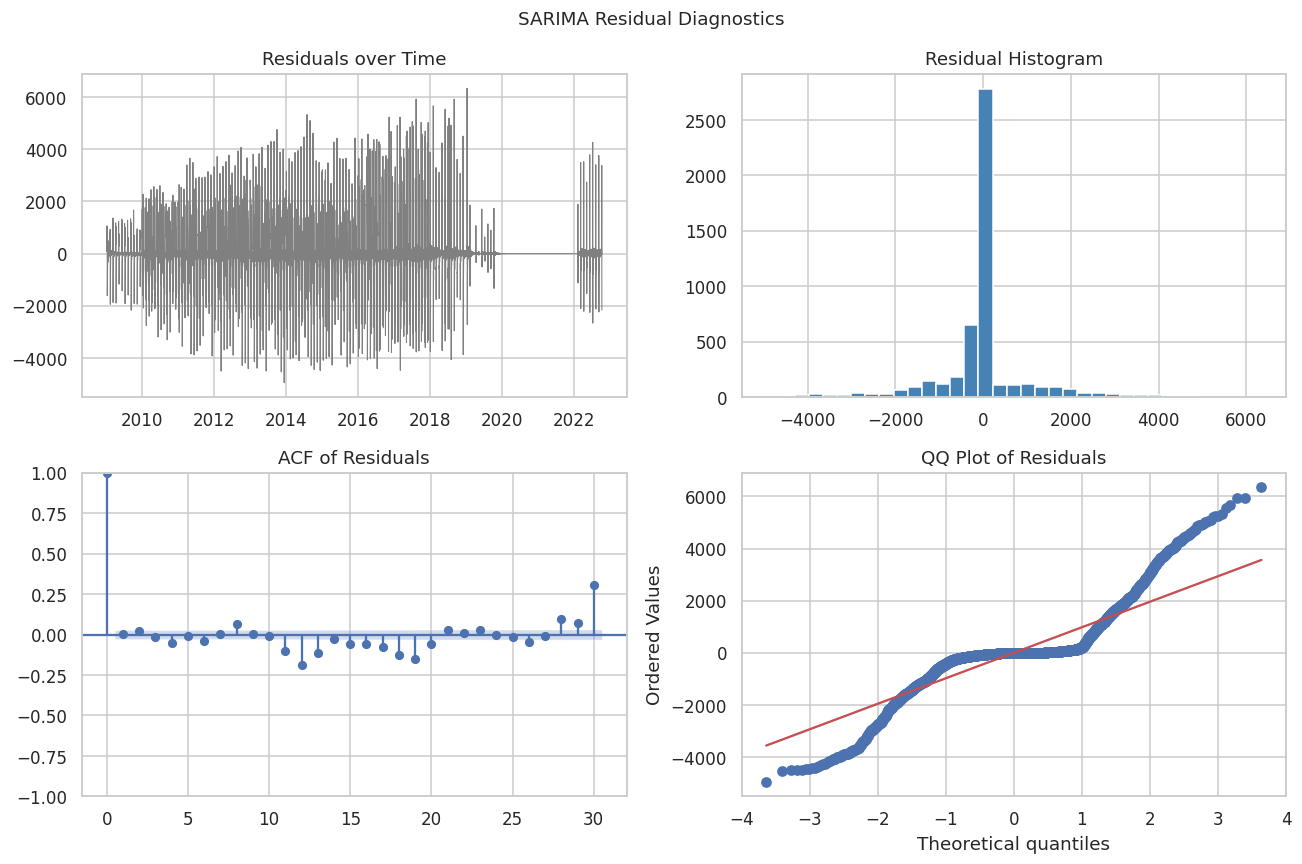

In [23]:
resid = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(resid, color='grey', lw=0.7)
axes[0,0].set_title('Residuals over Time')

axes[0,1].hist(resid, bins=35, color='steelblue', edgecolor='white')
axes[0,1].set_title('Residual Histogram')

plot_acf(resid, lags=30, ax=axes[1,0])
axes[1,0].set_title('ACF of Residuals')

sp_stats.probplot(resid, dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ Plot of Residuals')

plt.suptitle('SARIMA Residual Diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig('fig10_residual_diagnostics.png', bbox_inches='tight')
plt.show()

##SARIMA Forecast with 95% Confidence Interval

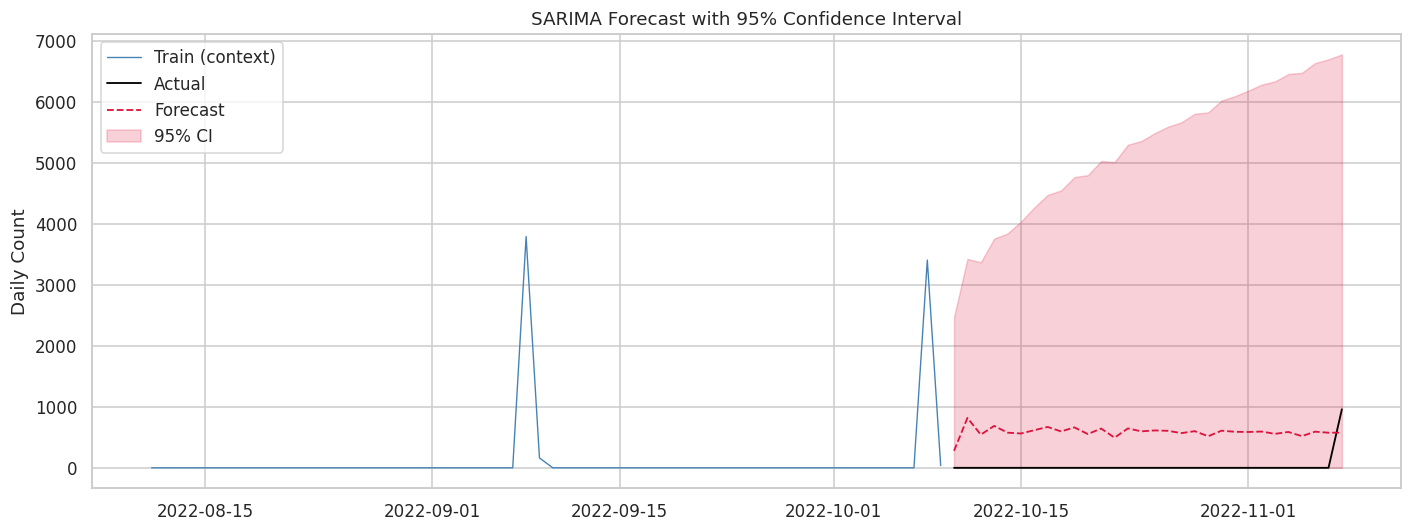

In [24]:
fc_obj  = sarima_fit.get_forecast(steps=HOLDOUT)
fc_mean = fc_obj.predicted_mean
fc_ci   = fc_obj.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(context.index,  context.values,  color='steelblue', lw=0.9, label='Train (context)')
ax.plot(test.index,     test.values,     color='black',     lw=1.2, label='Actual')
ax.plot(fc_mean.index,  fc_mean.values,  color='crimson',   lw=1.2, ls='--', label='Forecast')
ax.fill_between(fc_ci.index,
                fc_ci.iloc[:,0].clip(lower=0), fc_ci.iloc[:,1],
                color='crimson', alpha=0.2, label='95% CI')
ax.set_title('SARIMA Forecast with 95% Confidence Interval')
ax.legend(); ax.set_ylabel('Daily Count')
plt.tight_layout()
plt.savefig('fig11_sarima_ci.png', bbox_inches='tight')
plt.show()

##Model Comparison Summary


           MODEL COMPARISON SUMMARY
                                           MAE     RMSE          MAPE     R2
Model                                                                       
Linear Regression (Fourier + Trend)     181.73   216.77  1.548659e+13  -0.58
Forecast via STL Decomposition          429.99  1103.94  3.979901e+13 -40.04
Holt-Winters (additive + damped trend)  839.46   850.32  8.351194e+13 -23.35
ARIMA(2, 1, 4)                          601.57   609.37  5.901466e+13 -11.50
SARIMA(1, 1, 3)x(1, 0, 1, 7)            581.59   588.51  5.687820e+13 -10.66


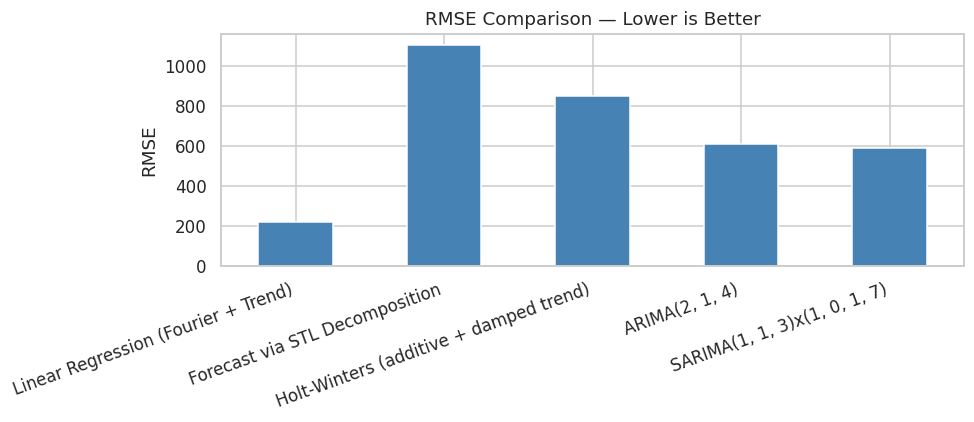


Saved figures: ['fig01_raw_rolling.png', 'fig02_transformations.png', 'fig03_moving_averages.png', 'fig04_classical_additive.png', 'fig04_classical_multiplicative.png', 'fig05_stl.png', 'fig06_detrend_deseasonal.png', 'fig07_acf_pacf.png', 'fig08_stationarity.png', 'fig09_forecast_comparison.png', 'fig10_residual_diagnostics.png', 'fig11_sarima_ci.png', 'fig12_rmse_comparison.png']


In [25]:
res_df = pd.DataFrame(results).set_index('Model').round(2)
print('\n' + '='*60)
print('           MODEL COMPARISON SUMMARY')
print('='*60)
print(res_df.to_string())
print('='*60)

fig, ax = plt.subplots(figsize=(9, 4))
res_df['RMSE'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('RMSE Comparison — Lower is Better')
ax.set_ylabel('RMSE'); ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig12_rmse_comparison.png', bbox_inches='tight')
plt.show()

import glob
print('\nSaved figures:', sorted(glob.glob('fig*.png')))